# 📊 Consumer Food Spending Analysis

### Author: Amankwa  
### Objective:
To analyze the factors influencing consumer food spending using statistical and regression techniques.

### Tools Used:
- Python (Pandas, Seaborn, Matplotlib)
- Statsmodels (OLS Regression)


In [29]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
# Load dataset from Excel file
# NOTE: File path is local — this may need to be changed when others run it
df = pd.read_excel(r"data/Eight_Databases.xlsx",
                   sheet_name="Consumer Food")

# Display first few rows to understand structure
df.head()

,Annual Food Spending ($),Annual Household Income ($),Non mortgage household debt ($),Region: 1 = NE 2 = MW 3 = S 4 = W,Location: 1 = Metro 2 = Outside Metro
0,8909,56697.446250,23179.877430,1,1
1,5684,35945.485150,7051.876096,1,1
2,10706,52686.830385,16148.835371,1,1
3,14112,74041.208942,21839.157184,1,1
4,13855,63181.852410,18865.962161,1,1


In [31]:
# Rename columns for easier analysis
df.columns = ["FoodSpending", "Income", "Debt", "Region", "Location"]

# Check for missing values
# Important to ensure data quality before analysis
print(df.isnull().sum())

FoodSpending    0
Income          0
Debt            0
Region          0
Location        0
dtype: int64


In [32]:
# Summary statistics to understand distribution of variables
df.describe()

# Insight:
# - Average food spending is around 8966
# - Income shows large variation (std ≈ 14661)
# - Debt also varies widely

,FoodSpending,Income,Debt,Region,Location
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,8966.065000,55552.390332,15604.157678,2.450000,1.400000
std,3125.007986,14661.360060,8583.539127,1.185126,0.491127
min,2587.000000,21646.611812,0.000000,1.000000,1.000000
25%,6933.750000,46162.964168,9191.929887,1.000000,1.000000
50%,8932.000000,54957.470866,16100.247865,2.000000,1.000000
75%,10950.000000,64933.544637,21259.126938,4.000000,2.000000
max,17740.000000,96132.202038,36373.939806,4.000000,2.000000


              FoodSpending    Income      Debt    Region  Location
FoodSpending      1.000000  0.859343  0.023936 -0.023727 -0.184612
Income            0.859343  1.000000 -0.001989 -0.007384 -0.092894
Debt              0.023936 -0.001989  1.000000  0.228369  0.008522
Region           -0.023727 -0.007384  0.228369  1.000000  0.120869
Location         -0.184612 -0.092894  0.008522  0.120869  1.000000


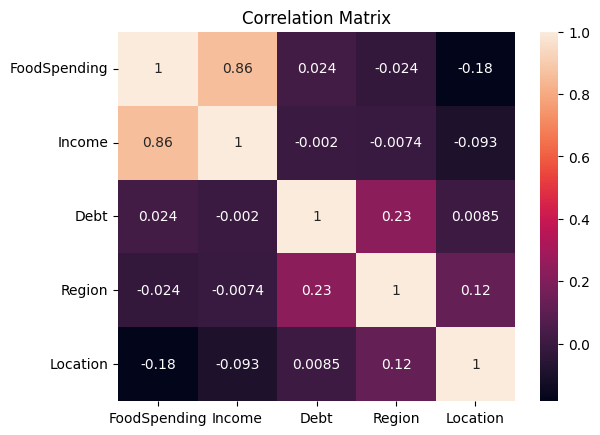

In [33]:
# Compute correlation matrix
corr = df.corr()

# Display correlation values
print(corr)

# Visualize correlations using heatmap
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

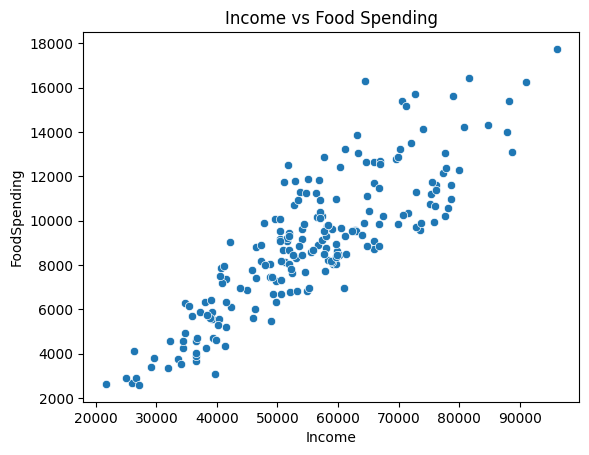

In [34]:
# Scatter plot to examine relationship between Income and Food Spending
sns.scatterplot(x="Income", y="FoodSpending", data=df)
plt.title("Income vs Food Spending")
plt.show()

### Interpretation:
There is a clear positive relationship between income and food spending.

As income increases, food spending also tends to increase. 
This supports the earlier correlation result (≈ 0.86), indicating a strong linear relationship.

This suggests that income is likely to be a strong predictor in the regression model.

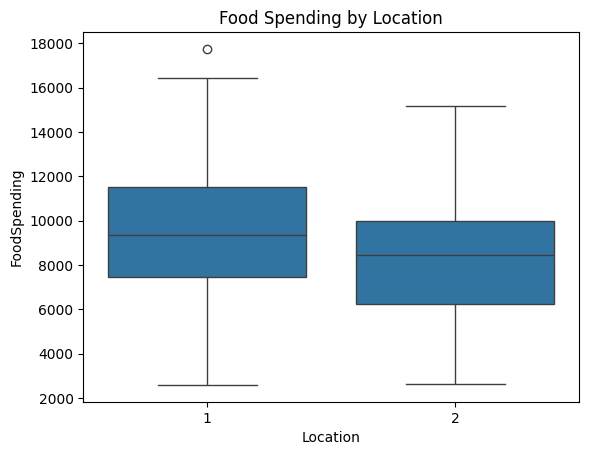

In [35]:
# Boxplot to compare food spending across locations
sns.boxplot(x="Location", y="FoodSpending", data=df)
plt.title("Food Spending by Location")
plt.show()

### Interpretation:
There is a noticeable difference in food spending between locations.

Households in different locations (Metro vs Outside Metro) show variation in spending patterns.

This suggests that location may influence consumer behavior and should be included in the model.

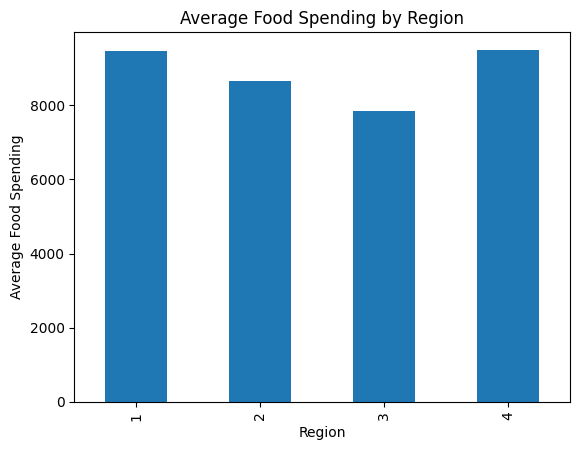

In [36]:
# Average food spending by region
df.groupby("Region")["FoodSpending"].mean().plot(kind="bar")
plt.title("Average Food Spending by Region")
plt.ylabel("Average Food Spending")
plt.show()

### Interpretation:
Average food spending varies slightly across regions.

However, the differences are not very large, suggesting that region may not be a strong predictor.

This aligns with the regression results where region variables were not statistically significant.

In [37]:
# Convert categorical variables into dummy variables
df = pd.get_dummies(df, columns=["Region", "Location"], drop_first=True)

# Convert boolean columns to integers (important for regression)
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

### Interpretation:
Categorical variables (Region and Location) are converted into dummy variables.

This allows them to be included in the regression model as numerical predictors.

The first category is dropped to avoid multicollinearity (dummy variable trap).

In [38]:
# Define independent and dependent variables
X = df.drop("FoodSpending", axis=1)
y = df["FoodSpending"]

# Add constant for intercept
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           FoodSpending   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     97.64
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           9.30e-56
Time:                        11:41:43   Log-Likelihood:                -1753.2
No. Observations:                 200   AIC:                             3520.
Df Residuals:                     193   BIC:                             3544.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -751.5996    536.915     -1.400      0.1

### Interpretation of Regression Results:

- Income is highly significant (p < 0.05), indicating a strong positive effect on food spending.
- Debt is not statistically significant, suggesting it does not strongly influence spending.
- Region variables are not significant, meaning regional differences are minimal.
- Location_2 is statistically significant, indicating location affects spending behavior.

- R-squared = 0.752:
  The model explains about 75.2% of the variation in food spending, which indicates a good fit.

- The large condition number suggests possible multicollinearity or scaling issues, which may require further investigation.